In [48]:
import pandas as pd

In [49]:
import numpy as np

In [50]:
data = pd.read_csv('data.csv')

In [51]:
data.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

In [53]:
data["Total_potential_savings"] = data["Potential_Savings_Groceries"]+data["Potential_Savings_Transport"]+data["Potential_Savings_Eating_Out"]+data["Potential_Savings_Entertainment"]+data["Potential_Savings_Healthcare"]+data["Potential_Savings_Utilities"]+data["Potential_Savings_Education"]+data["Potential_Savings_Miscellaneous"]

In [54]:
data.drop(columns=["Potential_Savings_Groceries","Potential_Savings_Transport","Potential_Savings_Eating_Out","Potential_Savings_Entertainment","Potential_Savings_Healthcare","Potential_Savings_Utilities","Potential_Savings_Education","Potential_Savings_Miscellaneous"], inplace=True)

In [55]:
data.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Total_potential_savings
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948,6200.537192,11265.627707,3507.222841
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376,1923.176434,9676.818733,1482.618056
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808,7050.360422,13891.450624,3551.316456
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,6128.550387,4571.118217,0.000000,2526.055712,16.455440,16694.965136,31617.953615,6078.520570
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982,1874.099434,6265.700532,1511.357063


In [56]:
data.drop("Desired_Savings_Percentage", axis=1, inplace=True)

In [57]:
## Dividing all the numberic columns by income by 100 to convert them into percentage format other than age, dependents and total potential savings
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
columns_to_convert = [col for col in numeric_columns if col not in ["Age", "Dependents"]]
data[columns_to_convert] = data[columns_to_convert].div(data["Income"], axis=0) * 100

In [58]:
data.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings,Disposable_Income,Total_potential_savings
0,100.0,49,0,Self_Employed,Tier_1,30.0,0.000000,4.943159,14.917515,5.907556,3.700501,3.441485,6.523234,3.465524,0.000000,1.862850,13.890948,25.238176,7.857166
1,100.0,34,2,Retired,Tier_2,20.0,0.000000,3.237409,10.493640,5.744972,2.417766,3.910263,6.054461,4.234590,5.777380,2.100761,7.160376,36.028758,5.520088
2,100.0,35,1,Student,Tier_3,15.0,9.156884,4.371461,12.534291,6.395770,3.005532,3.421459,6.687745,4.325232,6.273926,1.247570,13.997808,27.580129,7.050795
3,100.0,21,0,Self_Employed,Tier_3,15.0,6.711745,4.819269,14.479387,7.004177,4.967936,2.817187,6.040623,4.505536,0.000000,2.489814,16.455440,31.164326,5.991311
4,100.0,52,4,Professional,Tier_2,20.0,12.512860,2.556382,12.198171,5.130214,2.785203,2.653987,4.392670,4.699829,5.809846,2.072380,7.533982,25.188459,6.075738


In [59]:
data.drop("Income", axis=1, inplace=True)

In [60]:
data.head()

,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings,Disposable_Income,Total_potential_savings
0,49,0,Self_Employed,Tier_1,30.0,0.000000,4.943159,14.917515,5.907556,3.700501,3.441485,6.523234,3.465524,0.000000,1.862850,13.890948,25.238176,7.857166
1,34,2,Retired,Tier_2,20.0,0.000000,3.237409,10.493640,5.744972,2.417766,3.910263,6.054461,4.234590,5.777380,2.100761,7.160376,36.028758,5.520088
2,35,1,Student,Tier_3,15.0,9.156884,4.371461,12.534291,6.395770,3.005532,3.421459,6.687745,4.325232,6.273926,1.247570,13.997808,27.580129,7.050795
3,21,0,Self_Employed,Tier_3,15.0,6.711745,4.819269,14.479387,7.004177,4.967936,2.817187,6.040623,4.505536,0.000000,2.489814,16.455440,31.164326,5.991311
4,52,4,Professional,Tier_2,20.0,12.512860,2.556382,12.198171,5.130214,2.785203,2.653987,4.392670,4.699829,5.809846,2.072380,7.533982,25.188459,6.075738


In [61]:
data.Occupation.value_counts()

Occupation
Retired          5019
Professional     5011
Student          5003
Self_Employed    4967
Name: count, dtype: int64

In [62]:
data.City_Tier.value_counts()

City_Tier
Tier_2    10068
Tier_1     5934
Tier_3     3998
Name: count, dtype: int64

In [63]:
data.drop("Desired_Savings", axis=1, inplace=True)

In [64]:
data.head()

,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings
0,49,0,Self_Employed,Tier_1,30.0,0.000000,4.943159,14.917515,5.907556,3.700501,3.441485,6.523234,3.465524,0.000000,1.862850,25.238176,7.857166
1,34,2,Retired,Tier_2,20.0,0.000000,3.237409,10.493640,5.744972,2.417766,3.910263,6.054461,4.234590,5.777380,2.100761,36.028758,5.520088
2,35,1,Student,Tier_3,15.0,9.156884,4.371461,12.534291,6.395770,3.005532,3.421459,6.687745,4.325232,6.273926,1.247570,27.580129,7.050795
3,21,0,Self_Employed,Tier_3,15.0,6.711745,4.819269,14.479387,7.004177,4.967936,2.817187,6.040623,4.505536,0.000000,2.489814,31.164326,5.991311
4,52,4,Professional,Tier_2,20.0,12.512860,2.556382,12.198171,5.130214,2.785203,2.653987,4.392670,4.699829,5.809846,2.072380,25.188459,6.075738


<Axes: ylabel='Frequency'>

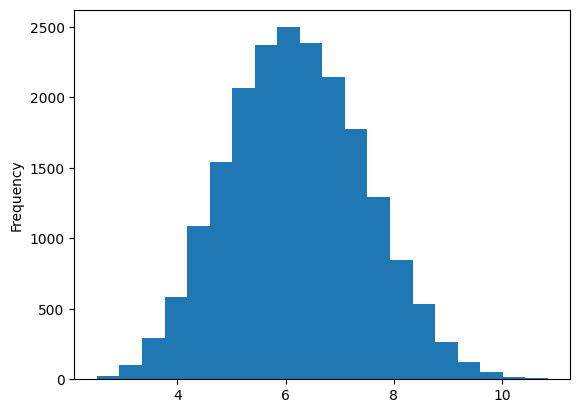

In [65]:
data.Total_potential_savings.plot.hist(bins=20)

In [66]:
data["Savings_Category"] = pd.cut(data["Total_potential_savings"], bins=[-1, 2, 4, 6, 8, 100], labels=["Very Low", "Low", "Medium", "High", "Very High"])

In [67]:
data.head()

,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,Self_Employed,Tier_1,30.0,0.000000,4.943159,14.917515,5.907556,3.700501,3.441485,6.523234,3.465524,0.000000,1.862850,25.238176,7.857166,High
1,34,2,Retired,Tier_2,20.0,0.000000,3.237409,10.493640,5.744972,2.417766,3.910263,6.054461,4.234590,5.777380,2.100761,36.028758,5.520088,Medium
2,35,1,Student,Tier_3,15.0,9.156884,4.371461,12.534291,6.395770,3.005532,3.421459,6.687745,4.325232,6.273926,1.247570,27.580129,7.050795,High
3,21,0,Self_Employed,Tier_3,15.0,6.711745,4.819269,14.479387,7.004177,4.967936,2.817187,6.040623,4.505536,0.000000,2.489814,31.164326,5.991311,Medium
4,52,4,Professional,Tier_2,20.0,12.512860,2.556382,12.198171,5.130214,2.785203,2.653987,4.392670,4.699829,5.809846,2.072380,25.188459,6.075738,High


In [68]:
#### Change all numeric columns to 2 decimal places

numeric_columns = data.select_dtypes(include=[np.number]).columns
data[numeric_columns] = data[numeric_columns].round(2)
data.head()

,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,Self_Employed,Tier_1,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,7.86,High
1,34,2,Retired,Tier_2,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,5.52,Medium
2,35,1,Student,Tier_3,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,7.05,High
3,21,0,Self_Employed,Tier_3,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,5.99,Medium
4,52,4,Professional,Tier_2,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,6.08,High


In [ ]:
## data.drop(columns=["Total_potential_savings"], inplace=True)

In [69]:
data.head()

,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,Self_Employed,Tier_1,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,7.86,High
1,34,2,Retired,Tier_2,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,5.52,Medium
2,35,1,Student,Tier_3,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,7.05,High
3,21,0,Self_Employed,Tier_3,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,5.99,Medium
4,52,4,Professional,Tier_2,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,6.08,High


In [70]:
data.drop("Occupation", axis=1, inplace=True)

In [71]:
data.head()

,Age,Dependents,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,Tier_1,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,7.86,High
1,34,2,Tier_2,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,5.52,Medium
2,35,1,Tier_3,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,7.05,High
3,21,0,Tier_3,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,5.99,Medium
4,52,4,Tier_2,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,6.08,High


In [72]:
data.City_Tier.replace({"Tier_1": 3, "Tier_2": 2, "Tier_3": 1}, inplace=True)

C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_31852\670605569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.City_Tier.replace({"Tier_1": 3, "Tier_2": 2, "Tier_3": 1}, inplace=True)
C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_31852\670605569.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', T

In [73]:
data.head()

,Age,Dependents,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,3,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,7.86,High
1,34,2,2,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,5.52,Medium
2,35,1,1,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,7.05,High
3,21,0,1,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,5.99,Medium
4,52,4,2,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,6.08,High


In [74]:
data.Savings_Category.value_counts()

Savings_Category
High         9376
Medium       8229
Very High    1692
Low           703
Very Low        0
Name: count, dtype: int64

In [89]:
### Feature importance and explainability modelling

In [75]:
data.Savings_Category.replace({"Very Low": 0, "Low": 1, "Medium": 2, "High": 3, "Very High": 4}, inplace=True)

C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_31852\1572753025.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Savings_Category.replace({"Very Low": 0, "Low": 1, "Medium": 2, "High": 3, "Very High": 4}, inplace=True)
C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_31852\1572753025.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_optio

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(["Savings_Category", "Total_potential_savings"], axis=1)
y = data["Savings_Category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
rf = RandomForestClassifier(random_state=42)

In [36]:
param_grid = {
    'n_estimators': [20, 50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 3]
}

In [37]:
cv = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [38]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [20, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [39]:
model = cv.best_estimator_

In [42]:
from sklearn.metrics import classification_report

In [43]:


y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       138
           2       0.53      0.36      0.43      1630
           3       0.50      0.77      0.61      1875
           4       0.00      0.00      0.00       357

    accuracy                           0.51      4000
   macro avg       0.26      0.28      0.26      4000
weighted avg       0.45      0.51      0.46      4000



d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [46]:
df_importances = pd.DataFrame(model.feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)

In [47]:
df_importances.head()

,importance
Groceries,0.253921
Utilities,0.171576
Eating_Out,0.116117
Entertainment,0.106703
Disposable_Income,0.085209


In [77]:
df_importances.reset_index(inplace=True)

In [78]:
df_importances.head()

,index,importance
0,Groceries,0.253921
1,Utilities,0.171576
2,Eating_Out,0.116117
3,Entertainment,0.106703
4,Disposable_Income,0.085209


In [79]:
df_importances.to_csv("feature_importances.csv", index=False)

In [80]:
data.head()

,Age,Dependents,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,3,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,7.86,3
1,34,2,2,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,5.52,2
2,35,1,1,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,7.05,3
3,21,0,1,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,5.99,2
4,52,4,2,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,6.08,3


In [81]:
data_check_df = data.drop(columns=["Savings_Category"], axis=1)

In [82]:
data_check_df.corr()

,Age,Dependents,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings
Age,1.000000,-0.011342,-0.002125,-0.001471,0.002705,0.003076,-0.007107,-0.000478,-0.003359,-0.002133,0.001711,-0.010215,0.001088,-0.006810,0.000725,-0.001768
Dependents,-0.011342,1.000000,0.005449,0.006638,-0.002216,0.005721,0.001577,-0.010275,-0.005240,0.002838,0.006630,-0.013481,0.649550,0.013236,-0.222311,0.049208
City_Tier,-0.002125,0.005449,1.000000,0.974810,0.007391,0.009195,-0.001354,-0.001857,-0.001972,0.002899,-0.005000,0.008020,0.002896,-0.000058,-0.563124,-0.005727
Rent,-0.001471,0.006638,0.974810,1.000000,0.005616,0.008506,0.000698,-0.000849,-0.003699,-0.000215,-0.006735,0.005488,0.004574,0.002178,-0.576527,-0.004418
Loan_Repayment,0.002705,-0.002216,0.007391,0.005616,1.000000,0.003151,0.002926,-0.006072,0.002224,0.007331,-0.008197,0.003084,0.002696,-0.009851,-0.694482,-0.000465
Insurance,0.003076,0.005721,0.009195,0.008506,0.003151,1.000000,0.001323,-0.009410,0.000939,-0.000961,0.001873,-0.006590,0.010878,0.005240,-0.099440,0.008996
Groceries,-0.007107,0.001577,-0.001354,0.000698,0.002926,0.001323,1.000000,0.001996,0.000780,0.001559,-0.000634,0.000542,0.008216,-0.012080,-0.153495,0.215124
Transport,-0.000478,-0.010275,-0.001857,-0.000849,-0.006072,-0.009410,0.001996,1.000000,0.000254,-0.004779,-0.001243,0.014793,-0.013800,0.001400,-0.079428,0.116121
Eating_Out,-0.003359,-0.005240,-0.001972,-0.003699,0.002224,0.000939,0.000780,0.000254,1.000000,0.004406,0.000739,-0.005747,-0.005156,-0.000354,-0.087072,0.121377
Entertainment,-0.002133,0.002838,0.002899,-0.000215,0.007331,-0.000961,0.001559,-0.004779,0.004406,1.000000,0.002842,0.004435,-0.005621,0.009231,-0.093678,0.116594


In [85]:
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=["Very Low", "Low", "Medium", "High", "Very High"], mode='classification')

In [86]:
explanation = explainer.explain_instance(X_test.iloc[0].values, model.predict_proba, num_features=5)

d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [92]:
import pickle
import dill

with open("lime_explainer.pkl", "wb") as f:
    dill.dump(explainer, f)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
print(explanation.as_list())

[('Utilities > 7.02', -0.03909958601333127), ('11.26 < Groceries <= 12.54', 0.03273129334073776), ('2.76 < Eating_Out <= 3.51', 0.018542812345785944), ('Transport > 7.24', -0.014370545028306154), ('2.73 < Entertainment <= 3.49', 0.013059836731977506)]


In [ ]:
### Clustering analyzer

In [93]:
data.head()

,Age,Dependents,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,Total_potential_savings,Savings_Category
0,49,0,3,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,7.86,3
1,34,2,2,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,5.52,2
2,35,1,1,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,7.05,3
3,21,0,1,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,5.99,2
4,52,4,2,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,6.08,3


In [94]:
features = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
    "Eating_Out", "Entertainment", "Utilities", "Healthcare",
    "Education", "Miscellaneous", "Disposable_Income"
]

In [ ]:
pdf = data[features]

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pdf)

In [101]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    

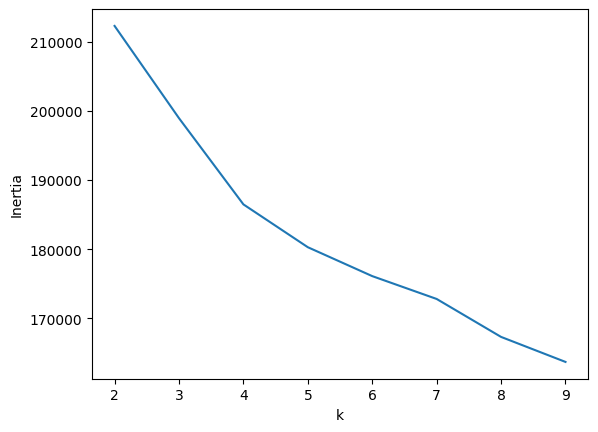

In [102]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [103]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pdf["cluster"] = clusters

C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_31852\2239060242.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf["cluster"] = clusters


In [104]:
cluster_summary = pdf.groupby("cluster").mean()
print(cluster_summary)

              Rent  Loan_Repayment  Insurance  Groceries  Transport  \
cluster                                                               
0        22.367741       14.786354   3.555446  12.651967   6.517490   
1        18.437932        1.178873   3.464084  12.477090   6.482186   
2        21.425544        3.226869   3.464120  12.476208   6.508955   
3        30.000000        1.341379   3.511364  12.506944   6.507628   

         Eating_Out  Entertainment  Utilities  Healthcare  Education  \
cluster                                                                
0          3.542611       3.539266   6.067753    4.018053   6.753819   
1          3.502499       3.468676   6.018004    3.983718   7.516114   
2          3.496273       3.466516   5.984173    4.003411   0.000000   
3          3.484899       3.490161   5.975976    3.982036   7.508914   

         Miscellaneous  Disposable_Income  
cluster                                    
0             2.010575          14.188807  
1       

In [105]:
with open("cluster.pkl", "wb") as f:
    pickle.dump(kmeans, f)

In [106]:
pdf.head()

,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,cluster
0,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,2
1,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,1
2,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,1
3,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,2
4,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,0


In [108]:
meta = data[["City_Tier", "Dependents"]].copy()

In [109]:
df_analysis = pd.concat([pdf, meta], axis=1)

In [110]:
df_analysis.head()

,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Disposable_Income,cluster,City_Tier,Dependents
0,30.0,0.00,4.94,14.92,5.91,3.70,3.44,6.52,3.47,0.00,1.86,25.24,2,3,0
1,20.0,0.00,3.24,10.49,5.74,2.42,3.91,6.05,4.23,5.78,2.10,36.03,1,2,2
2,15.0,9.16,4.37,12.53,6.40,3.01,3.42,6.69,4.33,6.27,1.25,27.58,1,1,1
3,15.0,6.71,4.82,14.48,7.00,4.97,2.82,6.04,4.51,0.00,2.49,31.16,2,1,0
4,20.0,12.51,2.56,12.20,5.13,2.79,2.65,4.39,4.70,5.81,2.07,25.19,0,2,4


In [111]:
group_cols = ["cluster", "Dependents", "City_Tier"]

In [114]:
df_analysis["percentile"] = df_analysis.groupby(group_cols)["Disposable_Income"] \
                     .rank(pct=True)

df_analysis["is_high_saver"] = df_analysis["percentile"] > 0.7

In [116]:
spending_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries",
    "Transport", "Eating_Out", "Entertainment", "Utilities",
    "Healthcare", "Education", "Miscellaneous"
]

# Average spending for high vs low savers
grouped = df_analysis.groupby(group_cols + ["is_high_saver"])[spending_cols].mean().reset_index()

In [117]:
pivot = grouped.pivot_table(
    index=group_cols,
    columns="is_high_saver",
    values=spending_cols
)

# Flatten column names
pivot.columns = [f"{col}_{int(flag)}" for col, flag in pivot.columns]
pivot = pivot.reset_index()

In [118]:
for col in spending_cols:
    pivot[f"{col}_diff"] = pivot[f"{col}_1"] - pivot[f"{col}_0"]

In [119]:
def get_recommendations(user_row, pivot_df, top_n=3):
    # Extract user group
    key = (
        user_row["cluster"],
        user_row["Dependents"],
        user_row["City_Tier"]
    )
    
    group_data = pivot_df[
        (pivot_df["cluster"] == key[0]) &
        (pivot_df["Dependents"] == key[1]) &
        (pivot_df["City_Tier"] == key[2])
    ]
    
    if group_data.empty:
        return ["Not enough similar users for comparison"]
    
    row = group_data.iloc[0]
    
    recommendations = []
    
    for col in spending_cols:
        diff = row[f"{col}_diff"]
        user_val = user_row[col]
        high_val = row[f"{col}_1"]
        
        # Only suggest if user is worse than high savers
        if diff < 0 and user_val > high_val:
            recommendations.append((col, abs(diff), user_val - high_val))
    
    # Sort by impact
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)
    
    return recommendations[:top_n]

In [120]:
def generate_advice(recommendations):
    advice = []
    
    for col, impact, gap in recommendations:
        advice.append(
            f"Reduce {col.replace('_', ' ')} by ~{round(gap, 2)}% "
            f"(people like you spend {round(impact, 2)}% less here)"
        )
    
    return advice

In [122]:
user = df_analysis.iloc[0]

recs = get_recommendations(user, pivot)
advice = generate_advice(recs)

for a in advice:
    print(a)

Reduce Groceries by ~3.16% (people like you spend 1.02% less here)
Reduce Utilities by ~1.11% (people like you spend 0.8% less here)
Reduce Insurance by ~1.72% (people like you spend 0.33% less here)
